# S&P 500 Options: Feature Engineering

The thesis of this case study is that implied variance is priced above the variance that
subsequently realizes, and that the gap is wider for some S&P 500 names than others. The matrix
built here carries that gap, the surface it is quoted on, the realized volatility it is measured
against, and the cost of the straddle that would have to be sold to collect it.

One property of the data shapes every window below. A 30-day at-the-money straddle is **not
listed for every symbol on every session**, and B.1 measures how often two consecutive quotes
are more than one session apart. A window counted in straddle rows is therefore not a window
counted in sessions, and this notebook counts sessions.

## Learning objectives

- Write down, for every group of features, how many sessions back it reaches and how old its
  newest input is, and put those two numbers in the configuration before writing the code
- Count every trailing window on the underlying's session grid rather than on the rows an
  intermittently quoted instrument happens to occupy
- Separate what is being traded - the straddle, and the sensitivities of its price to spot,
  time and volatility - from what is being predicted about, which is the volatility the options
  are quoted at, and compare the second across the symbols quoted on the same day
- Show that withholding the holdout leaves every feature value unchanged

## Book reference, prerequisites and artifacts

Chapter 8, Sections 8.1-8.6. Reads pre-materialized 30-day ATM straddles via
`load_sp500_options_straddles()`, underlying daily bars via `load_sp500_daily_bars()`, and
`config/setup.yaml`. Writes `features/financial.parquet` with a `.digest.json` sidecar.
[`04_model_based_features`](04_model_based_features.ipynb) reads it for the span of dates its
walk-forward folds are cut on, and adds features that are themselves fitted models of the
underlying's volatility. [`05_evaluation`](05_evaluation.ipynb) reads every column of it and
tests fold by fold whether any of them predicts.

In [1]:
"""S&P 500 Options: Feature Engineering."""

import math
import warnings
from collections import Counter
from datetime import date

import polars as pl
import yaml

from case_studies.sp500_options._underlying_returns import reconcile_underlying_log_returns
from case_studies.utils.artifact_digest import value_digest, write_artifact
from case_studies.utils.feature_engineering import (
    EPS,
    assert_values_agree,
    assign_families,
    cross_sectional_percentile,
    families_from_config,
    family_coverage,
    plot_coverage_through_time,
    plot_cross_sectional_dispersion,
    plot_feature_distributions,
    plot_persistence,
    plot_redundancy_clusters,
    plot_timing_contract,
    register_frame,
    trailing_return,
    trailing_volatility,
    warmup_audit,
)
from data import load_sp500_daily_bars, load_sp500_options_straddles
from utils.paths import display_path, get_case_study_dir

warnings.filterwarnings("ignore")

CASE_DIR = get_case_study_dir("sp500_options")
FEATURES_DIR = CASE_DIR / "features"

Production runs `START_DATE` as `None`; CI overrides it to shorten the window. There is no
symbol cap, because the cross-sectional percentiles below rank within a date and need the
whole cross-section to rank over.

In [2]:
START_DATE = None

## Configuration

Every window, threshold, ranked column and the null policy are declared in `config/setup.yaml`
and bound here rather than typed in. The register below, the warmup assertion in D.2 and the
timing figure all have to state the same lookback for a family, and they can only be checked
against each other if there is one place the number comes from.

One of those settings is specific to this data. Because a straddle is not quoted on every
session, a window of 252 sessions holds fewer than 252 quotes, and
`min_observations_fraction` is the share of the window that must carry one before the window
produces a value at all. The bound value is printed below, and C.4 measures what it buys and
what it costs.

In [3]:
setup = yaml.safe_load((CASE_DIR / "config" / "setup.yaml").read_text())
FEATURES = setup["features"]
FAMILIES = families_from_config(setup)
WINDOWS = FEATURES["windows"]
LEVEL = FEATURES["thresholds"]
RANKED = FEATURES["ranked"]
METADATA = list(FEATURES["metadata"])
NULL_POLICY = list(FEATURES["null_policy"])
TARGET_DTE = FEATURES["target_dte"]
HOLD_SESSIONS = FEATURES["hold_sessions"]
MIN_OBS = FEATURES["min_observations_fraction"]
PERIODS_PER_YEAR = setup["evaluation"]["periods_per_year"]
HOLDOUT_START = date.fromisoformat(setup["evaluation"]["holdout_start"])

# The panel key, and the segment every trailing window is taken within. `sec_id` is the security
# identity: a symbol that is reassigned to a different company is a different series, not a move.
SEGMENT = ["symbol", "sec_id"]
PANEL_KEY = ["symbol", "instrument_id", "timestamp"]

print(
    f"{len(FAMILIES)} declared families, {TARGET_DTE}-day straddle held ~{HOLD_SESSIONS} sessions"
)
print(f"A trailing window produces a value once {MIN_OBS:.0%} of its sessions carry a quote")
print(f"Holdout starts {HOLDOUT_START}; Section D rebuilds the panel without it")

8 declared families, 30-day straddle held ~21 sessions
A trailing window produces a value once 80% of its sessions carry a quote
Holdout starts 2021-01-01; Section D rebuilds the panel without it


## A. What the thesis says should carry information

The quantity the whole case study rests on is the variance risk premium: at-the-money implied
volatility minus the realized volatility of the same underlying. Selling a straddle collects it,
and the claim is that it is positive on average and unevenly distributed across names. It is
built at five horizons, because the horizon over which realized volatility is measured is a
modelling choice and not a fact, and as a difference, a ratio and a z-score, because a
five-point premium means one thing on a name that usually quotes at two and another on a name
that usually quotes at fifteen.

The remaining families are there to say whether the premium is collectable rather than merely
on offer. The instrument-state family is the cost side: an at-the-money option's quoted
spread is wide relative to its premium, and a straddle whose spread is in the top decile is one
whose edge is spent on entry. The realized-volatility and underlying families are the risk side.
The quality family predicts nothing by construction and is carried so that a model leaning on it
is visible.

The table below is the register: one row per family, declared in `config/setup.yaml` and read
from there by everything that has to agree with it. Its `frame` column says what a feature is
measured against - one symbol's own past, or every symbol quoted on the same day. That
distinction decides what the feature can be used for. The strategy sells some straddles and not
others on the same Friday, so only standing relative to the other names quoted that Friday can
drive it, which is what the four percentile columns record.

The `lag` column is zero on every row: straddle quotes and underlying closes are both dated to
the session that produced them, and the decision is taken at that session's close, so no feature
here is waiting on a value that arrives later than the decision it feeds.

In [4]:
register_frame(FAMILIES).select(
    ["family", "role", "inputs", "lookback (bars)", "lag (bars)", "frame"]
)

family,role,inputs,lookback (bars),lag (bars),frame
str,str,str,i64,i64,str
"""instrument_state""","""state""","""straddle quotes and Greeks""",5,0,"""one symbol's own straddle seri…"
"""surface_level""","""signal""","""straddle implied volatilities""",0,0,"""one symbol on one session"""
"""surface_dynamics""","""signal""","""straddle implied volatilities""",252,0,"""one symbol's own session histo…"
"""variance_risk_premium""","""signal""","""straddle implied volatility an…",252,0,"""one symbol's own session histo…"
"""realized_volatility""","""state""","""underlying adjusted closes""",63,0,"""one security identity's own se…"
"""cross_sectional""","""signal""","""the level features named in fe…",21,0,"""every symbol quoted on the dec…"
"""underlying""","""state""","""underlying adjusted closes and…",21,0,"""one security identity's own se…"
"""quality""","""state""","""solver convergence codes""",0,0,"""one symbol on one session"""


## B. Inputs and their observability

Two sources arrive. The straddle panel is one row per symbol-session carrying the 30-day ATM
straddle's mid, bid, ask, implied volatilities, aggregated Greeks, days to expiry and solver
convergence codes. The underlying panel is one row per symbol-session carrying the close, the
cumulative adjustment factor, volume, and `sec_id` - the identity of the company the ticker
denoted on that session.

`sec_id` is the reason the underlying panel is loaded at all rather than the straddle panel
alone. A ticker reassigned from one company to another produces a price ratio that is not a
return, and `reconcile_underlying_log_returns` nulls it rather than letting it propagate through
every window that contains it. The join below fails loudly rather than dropping a straddle whose
identity cannot be established.

In [5]:
straddles = load_sp500_options_straddles()
underlying = load_sp500_daily_bars()
if START_DATE is not None:
    window = pl.lit(START_DATE).str.to_date()
    straddles = straddles.filter(pl.col("timestamp") >= window)
    underlying = underlying.filter(pl.col("timestamp") >= window)

print(f"{len(straddles):,} straddle quotes over {straddles['symbol'].n_unique()} symbols")
print(f"{len(underlying):,} underlying sessions, {underlying['timestamp'].n_unique()} trading days")

361,010 straddle quotes over 627 symbols
635,703 underlying sessions, 1259 trading days


In [6]:
def attach_security_identity(straddle_df: pl.DataFrame, prices_df: pl.DataFrame) -> pl.DataFrame:
    """Attach the unique contemporaneous security identity to each straddle."""
    identity = prices_df.select("timestamp", "symbol", "sec_id")
    duplicate_keys = identity.group_by("timestamp", "symbol").len().filter(pl.col("len") != 1)
    if duplicate_keys.height:
        raise ValueError(
            "Underlying identity map is not unique on (timestamp, symbol): "
            f"{duplicate_keys.height} duplicate keys"
        )
    if identity["sec_id"].null_count():
        raise ValueError("Underlying identity map contains null sec_id values")
    joined = straddle_df.join(identity, on=["timestamp", "symbol"], how="left", validate="m:1")
    if joined["sec_id"].null_count():
        raise ValueError(
            "Straddle rows lack contemporaneous security identity: "
            f"{joined['sec_id'].null_count()} unmapped rows"
        )
    return joined

### B.1 The session grid, and why every window is counted on it

The straddle panel is sparse. Reindexing it onto the market's own session calendar is the single
structural decision in this notebook: on the grid below, `shift(5)` means five sessions and
`rolling(252)` means 252 sessions, for every symbol, whatever its quoting history. On the
straddle rows themselves it does not - the census printed here is what that costs.

The grid is the **market calendar**, not each security's own observed rows. The two differ on
only a handful of rows here, but they differ in the direction that matters: a security absent
from its own series for a stretch - a halt, or a ticker that resumes after a corporate action -
has consecutive rows that are not consecutive sessions, which is exactly the hole this section
exists to close. Building the span from the calendar and left-joining the security onto it makes
the absence explicit, so a return across it is null rather than silently spanning the gap.

In [7]:
STRADDLE_COLUMNS = [
    "instrument_id",
    "instr_mid",
    "instr_bid",
    "instr_ask",
    "instr_rel_spread",
    "instr_pct_of_S",
    "instr_dte",
    "instr_delta",
    "instr_gamma",
    "instr_theta",
    "instr_vega",
    "iv_atm",
    "call_iv",
    "put_iv",
    "call_convergence",
    "put_convergence",
    "qc_any_estimated_iv",
    "underlying_price",
]
quotes = attach_security_identity(straddles, underlying).select(
    ["timestamp", *SEGMENT, *STRADDLE_COLUMNS]
)

In [8]:
def session_grid(prices: pl.DataFrame) -> pl.DataFrame:
    """Every market session inside each security identity's own active span.

    The calendar is the union of sessions **any** security traded, not the rows this one happens
    to have, so a security absent for a stretch gets those sessions back as rows carrying no
    price - which is what stops a window closing over the absence.
    """
    calendar = prices.select("timestamp").unique().sort("timestamp")
    return (
        prices.group_by(SEGMENT)
        .agg(pl.col("timestamp").min().alias("_first"), pl.col("timestamp").max().alias("_last"))
        .join(calendar, how="cross")
        .filter(pl.col("timestamp").is_between(pl.col("_first"), pl.col("_last")))
        .select(["timestamp", *SEGMENT])
        .sort([*SEGMENT, "timestamp"])
    )

In [9]:
panel = (
    session_grid(underlying)
    .join(
        underlying.select(["timestamp", *SEGMENT, "close", "adj_factor", "volume"]),
        on=["timestamp", *SEGMENT],
        how="left",
    )
    .join(quotes, on=["timestamp", *SEGMENT], how="left")
    .sort([*SEGMENT, "timestamp"])
)
QUOTED = pl.col("instrument_id").is_not_null()

In [10]:
WIDEST = WINDOWS["iv_momentum"][-1]
on_rows = (
    straddles.select(["timestamp", "symbol", "strike", "expiration"])
    .join(underlying.select(["timestamp", *SEGMENT]), on=["timestamp", "symbol"])
    .join(
        panel.with_columns(pl.col("timestamp").rank("dense").alias("session")).select(
            "timestamp", *SEGMENT, "session"
        ),
        on=["timestamp", *SEGMENT],
    )
    .sort([*SEGMENT, "timestamp"])
    .with_columns(
        (pl.col("session") - pl.col("session").shift(WIDEST).over(SEGMENT)).alias("spanned"),
        (pl.col("session") - pl.col("session").shift(1).over(SEGMENT) == 1).alias("adjacent"),
        (
            (pl.col("strike") == pl.col("strike").shift(1).over(SEGMENT))
            & (pl.col("expiration") == pl.col("expiration").shift(1).over(SEGMENT))
        ).alias("same_contract"),
    )
)
spanned = on_rows.drop_nulls("spanned")
off_grid = spanned.filter(pl.col("spanned") != WIDEST)
pairs = on_rows.drop_nulls("adjacent")

# The same census for the underlying, which C.1 counts its windows on with every
# observation required: a run is one stretch of consecutive grid sessions on which the
# security carried no close.
absent = pl.col("close").is_null()
underlying_gaps = panel.select(
    absent.sum().alias("sessions"),
    (absent & ~absent.shift(1, fill_value=False).over(SEGMENT)).sum().alias("runs"),
).row(0, named=True)

In [11]:
print(f"{len(panel):,} session rows, {panel.filter(QUOTED).height:,} of them quoted")
print(
    f"consecutive quotes one session apart: {pairs['adjacent'].mean():.1%}; "
    f"on the same strike and expiration: {pairs['same_contract'].mean():.1%}"
)
print(
    f"a {WIDEST}-row shift on the straddle rows alone spans something other than {WIDEST} "
    f"sessions on {off_grid.height:,} of {spanned.height:,} rows "
    f"({off_grid.height / spanned.height:.1%}), up to {spanned['spanned'].max()} sessions"
)
print(
    f"the underlying carries no close on {underlying_gaps['sessions']:,} grid sessions, "
    f"in {underlying_gaps['runs']:,} runs"
)

635,727 session rows, 361,010 of them quoted
consecutive quotes one session apart: 92.1%; on the same strike and expiration: 32.0%
a 21-row shift on the straddle rows alone spans something other than 21 sessions on 167,106 of 347,904 rows (48.0%), up to 1026 sessions
the underlying carries no close on 35 grid sessions, in 13 runs


## C. Feature construction, one subsection per family

### C.1 Underlying returns and realized volatility

The underlying panel is dense - B.1's census counts the grid sessions it leaves without a close,
and the runs they fall in - so these windows are counted with every observation required, unlike
the straddle windows in C.4. `trailing_return` and `trailing_volatility` are the
shared primitives, called with `sec_id` in the segment so that neither a return nor a volatility
ever spans a security identity change. Realized volatility is the RV side of the premium and is
kept under its own `rv_` prefix rather than the primitive's `vol_` name, which is the name every
later stage reads.

In [12]:
def underlying_features(df: pl.DataFrame) -> pl.DataFrame:
    """Adjusted returns, realized volatility and relative volume, within one security identity."""
    df = reconcile_underlying_log_returns(df)
    volume_window = WINDOWS["volume_zscore"]
    mean = pl.col("volume").rolling_mean(volume_window).over(SEGMENT)
    std = pl.col("volume").rolling_std(volume_window).over(SEGMENT)
    return df.with_columns(
        *[
            trailing_return("adjusted_close", w, SEGMENT).alias(f"ret_{w}d")
            for w in WINDOWS["underlying_return"]
        ],
        *[
            trailing_volatility(
                "clean_log_return", w, SEGMENT, periods_per_year=PERIODS_PER_YEAR
            ).alias(f"rv_{w}d")
            for w in WINDOWS["realized_volatility"]
        ],
        ((pl.col("volume") - mean) / std.clip(lower_bound=EPS)).alias("volume_zscore"),
    )

### C.2 Instrument state

What the straddle costs and how it is exposed. `theta_vega_ratio` is time decay per unit of
volatility exposure - what the position earns for what it risks - and its denominator is floored
at the configured `vega_floor` rather than at the shared numerical guard, because a vega of a
thousandth is a real quote and the ratio is genuinely unreadable there.

`instr_ret_1d` and `instr_ret_5d` are **not returns anyone could have held**. The 30-day ATM
straddle is reselected each session, and the census in B.1 counts how rarely two consecutive
quotes are even the same strike and expiration - under a third of the time. The change in
`instr_mid` is therefore the change in the price of a rolling synthetic. It is carried because
that price level tracks what the option market charges for variance, and it is described here
so that no later stage reads it as a P&L.

In [13]:
def instrument_features(df: pl.DataFrame) -> pl.DataFrame:
    """Cost, exposure and price change of the straddle being traded."""
    mid = pl.col("instr_mid")
    return df.with_columns(
        (pl.col("instr_theta") / pl.col("instr_vega").clip(lower_bound=LEVEL["vega_floor"])).alias(
            "theta_vega_ratio"
        ),
        (pl.col("instr_dte") / TARGET_DTE).alias("dte_normalized"),
        pl.col("instr_delta").abs().alias("abs_net_delta"),
        *[
            (mid / mid.shift(w).over(SEGMENT).clip(lower_bound=EPS) - 1).alias(f"instr_ret_{w}d")
            for w in WINDOWS["instrument_return"]
        ],
    )

### C.3 The variance risk premium and the surface level

The premium is implied minus realized at each realized-volatility horizon, on one scale because
both are annualized volatilities. The ratio is the same contrast in multiplicative form, floored
at the configured `realized_volatility_floor`: a name whose underlying has not moved at all over
the reference window would otherwise divide by nothing and dominate every ranking.

`iv_skew_atm` is the call implied volatility minus the put implied volatility at the same strike.
For a true at-the-money pair put-call parity forces these together, so what it measures is the
residual disagreement between the two legs - a quote-quality signal as much as a surface one.

In [14]:
def premium_features(df: pl.DataFrame) -> pl.DataFrame:
    """Implied minus realized, at every realized-volatility horizon."""
    reference = WINDOWS["vrp_reference"]
    return df.with_columns(
        *[(pl.col("iv_atm") - pl.col(f"rv_{w}d")).alias(f"vrp_{w}d") for w in WINDOWS["vrp"]],
        (
            pl.col("iv_atm")
            / pl.col(f"rv_{reference}d").clip(lower_bound=LEVEL["realized_volatility_floor"])
        ).alias("iv_rv_ratio"),
        (pl.col("call_iv") - pl.col("put_iv")).alias("iv_skew_atm"),
    )

### C.4 Surface and premium dynamics

Where implied volatility and the premium sit against their own recent history, and how far each
has moved. Both z-scores are trailing: the mean and standard deviation at each row come from that
row's own past, so nothing is estimated across the sample.

A trailing z-score subtracts the mean of the last *n* sessions and divides by their standard
deviation, so it says how unusual today's level is for this symbol rather than how high it is.
The shared primitives require every session in the window to carry a value before they return
one, which is the right rule on a dense price series and the wrong rule here: a symbol whose
straddle is quoted on four sessions out of five has no complete 252-session window anywhere in
the sample. `session_zscore` below is therefore written locally. It is the same trailing mean
over the same trailing dispersion, guarded the same way against a dispersion of zero, with one
addition - the number of sessions in the window that must actually carry a quote.

That number is what `min_observations_fraction` sets, and the cell after it measures the trade
the fraction makes. Requiring the whole window leaves the longest z-score defined on almost none
of the rows that carry a quote; the configured rule recovers most of them. What it costs is
comparability, because two z-scores over the same window that were computed from different
numbers of observations are not quite the same statistic, and nothing downstream is told which
it received.

In [15]:
def min_observations(window: int) -> int:
    """Quoted sessions a window must hold before it produces a value.

    Rounded **up**: the configured fraction is a floor, and rounding to nearest would accept
    a window below it - 63 sessions at 80% is 50.4, and 50 of 63 is 79.4%.
    """
    return max(2, math.ceil(window * MIN_OBS))


def session_zscore(column: str, window: int) -> pl.Expr:
    """Standardize against the trailing *window* sessions, however many are quoted."""
    observations = min_observations(window)
    mean = pl.col(column).rolling_mean(window, min_samples=observations).over(SEGMENT)
    std = pl.col(column).rolling_std(window, min_samples=observations).over(SEGMENT)
    return (pl.col(column) - mean) / std.clip(lower_bound=EPS)

The longest z-score is the one the rule decides, so it is the one to measure it on: the share of
quoted rows that carry a value under each of the two requirements.

In [16]:
LONGEST = WINDOWS["iv_zscore"][-1]
strict_mean = pl.col("iv_atm").rolling_mean(LONGEST, min_samples=LONGEST).over(SEGMENT)
strict_std = pl.col("iv_atm").rolling_std(LONGEST, min_samples=LONGEST).over(SEGMENT)
defined = (
    panel.with_columns(
        ((pl.col("iv_atm") - strict_mean) / strict_std.clip(lower_bound=EPS)).alias("_every"),
        session_zscore("iv_atm", LONGEST).alias("_configured"),
    )
    .filter(QUOTED)
    .select(
        pl.col("_every").is_not_null().mean().alias("every"),
        pl.col("_configured").is_not_null().mean().alias("configured"),
    )
    .row(0, named=True)
)
print(
    f"the {LONGEST}-session z-score is defined on {defined['every']:.1%} of quoted rows when every "
    f"session in the window must carry a quote, and on {defined['configured']:.1%} when "
    f"{min_observations(LONGEST)} of them must"
)

the 252-session z-score is defined on 6.8% of quoted rows when every session in the window must carry a quote, and on 57.0% when 202 of them must


In [17]:
def dynamics_features(df: pl.DataFrame) -> pl.DataFrame:
    """Trailing z-scores and changes of the surface and the premium."""
    reference = f"vrp_{WINDOWS['vrp_reference']}d"
    implied, cost = pl.col("iv_atm"), pl.col("instr_pct_of_S")
    momentum = WINDOWS["instrument_cost_momentum"]
    return df.with_columns(
        *[session_zscore("iv_atm", w).alias(f"iv_atm_z_{w}") for w in WINDOWS["iv_zscore"]],
        session_zscore(reference, WINDOWS["vrp_zscore"]).alias(
            f"vrp_zscore_{WINDOWS['vrp_zscore']}"
        ),
        *[
            (implied - implied.shift(w).over(SEGMENT)).alias(f"iv_mom_{w}d")
            for w in WINDOWS["iv_momentum"]
        ],
        *[
            (pl.col(reference) - pl.col(reference).shift(w).over(SEGMENT)).alias(f"vrp_mom_{w}d")
            for w in WINDOWS["vrp_momentum"]
        ],
        (cost - cost.shift(momentum).over(SEGMENT)).alias(f"instr_cost_mom_{momentum}d"),
    )

### C.5 Quality controls, the null policy, and cross-sectional standing

The two quality columns are indicators over the solver's own convergence codes. They are the
controls: a model that leans on them is reading the pricing engine rather than the market.

The null policy is applied here, once, and it is what defines the tradable set: a row is kept
when it was quoted and when the premium the thesis is about can be measured on it at the
reference horizon. Nothing else is required. A feature that is unavailable on a row is shipped
null on that row, because dropping the row instead turns the availability of one conditioning
feature into a screen on the universe - and one does exactly that here. The build below prices
it: a symbol quoted in bursts shorter than ten sessions never has a session ten back to compare
against, so requiring `iv_mom_10d` too drops the symbol rather than nulling one of its columns.

The percentiles are taken **after** the policy, because a percentile is a property of the
cross-section a decision is actually taken over, and a row that has been dropped is not in it.

In [18]:
def tradable_features(df: pl.DataFrame) -> pl.DataFrame:
    """Quality controls, the one null policy, then standing within the decision date."""
    converged = (pl.col("call_convergence") == "Converged") & (
        pl.col("put_convergence") == "Converged"
    )
    return (
        df.with_columns(converged.cast(pl.Float64).alias("qc_both_converged"))
        .filter(QUOTED)
        .drop_nulls(subset=NULL_POLICY)
        .with_columns(
            cross_sectional_percentile(source, "timestamp").alias(name)
            for source, name in RANKED.items()
        )
    )

The subsections compose into two functions rather than one. `build_grid` is everything computed
on the session grid, and it is the frame D.2 audits, because a warmup counted in rows is only a
warmup counted in sessions before the tradable set is cut out of it. `build_features` adds the
cut and the percentiles, and is what D.3 re-runs on a shorter panel. Order matters once: the
premium needs realized volatility, and the dynamics need the premium.

In [19]:
def build_grid(df: pl.DataFrame) -> pl.DataFrame:
    """Every trailing family, on one row per security-session."""
    return (
        df.pipe(underlying_features)
        .pipe(instrument_features)
        .pipe(premium_features)
        .pipe(dynamics_features)
    )


def build_features(df: pl.DataFrame) -> pl.DataFrame:
    """The tradable matrix: the grid, cut to quoted and warmed-up rows, then ranked."""
    return build_grid(df).pipe(tradable_features)

In [20]:
grid = build_grid(panel)
built = tradable_features(grid)
FEATURE_COLUMNS = [
    # instrument state
    "instr_rel_spread", "instr_pct_of_S", "instr_dte", "dte_normalized", "instr_delta",
    "abs_net_delta", "instr_gamma", "instr_theta", "instr_vega", "theta_vega_ratio",
    "instr_ret_1d", "instr_ret_5d",
    # surface level and dynamics
    "iv_atm", "call_iv", "put_iv", "iv_skew_atm", "iv_atm_z_63", "iv_atm_z_252",
    "iv_mom_5d", "iv_mom_10d", "iv_mom_21d",
    # variance risk premium
    "vrp_5d", "vrp_10d", "vrp_21d", "vrp_42d", "vrp_63d", "iv_rv_ratio", "vrp_zscore_252",
    "vrp_mom_5d", "vrp_mom_10d", "instr_cost_mom_5d",
    # realized volatility, cross-sectional standing, underlying, quality
    "rv_5d", "rv_10d", "rv_21d", "rv_42d", "rv_63d",
    "vrp_21d_pctl", "iv_atm_pctl", "spread_pctl", "iv_rv_ratio_pctl",
    "ret_1d", "ret_5d", "ret_10d", "ret_21d", "volume_zscore",
    "qc_both_converged", "qc_any_estimated_iv",
]  # fmt: skip
stricter = grid.filter(QUOTED).drop_nulls(subset=[*NULL_POLICY, "iv_mom_10d"])
print(f"{len(grid):,} security-sessions on the grid, {len(built):,} of them tradable")
print(f"{len(FEATURE_COLUMNS)} features declared across {len(FAMILIES)} register families")
print(
    f"requiring iv_mom_10d as well would leave {stricter['symbol'].n_unique()} of the "
    f"{built['symbol'].n_unique()} symbols the null policy keeps"
)

635,727 security-sessions on the grid, 354,265 of them tradable
47 features declared across 8 register families
requiring iv_mom_10d as well would leave 322 of the 620 symbols the null policy keeps


## D. The timing contract

### D.1 What each construction reads

Four kinds of operation appear above. A **rolling** window - the realized volatilities, the
relative volume, and the two z-score families - ends at its own row and reads a fixed number of
**sessions** backward within one security identity. A **shift** reads the row a fixed number of
sessions earlier in the same series, and is null when that session carried no quote. A
**contemporaneous** relation - the premium at each horizon, the ratio, the skew, the Greeks
ratios - reads one symbol on one session and no other date at all. A **cross-sectional**
statistic - the four percentiles - is taken with `.over("timestamp")`, so it reads every symbol
tradable on that date and nothing dated before or after it.

None of the four is fitted: no bound, scaler or encoder here has parameters estimated once and
applied to every row. D.2 checks the windows and D.3 checks all four at once.

### F4. The timing contract the register declares

Each bar runs leftward from the
decision to the oldest session that family reads, so its length is the lookback; a bar that
stopped short of the decision line on the right would be a family whose newest input is already
stale when the decision is taken. None of them does.

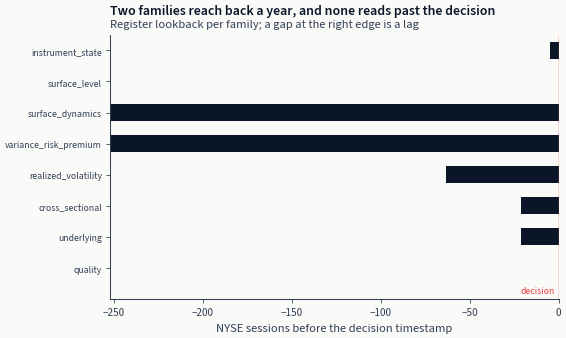

In [21]:
plot_timing_contract(
    FAMILIES,
    bar_unit="NYSE sessions",
    title="Two families reach back a year, and none reads past the decision",
    subtitle="Register lookback per family; a gap at the right edge is a lag",
    alt=(
        "Horizontal bars, one per feature family, each extending leftward from the decision line "
        "by that family's lookback: 252 sessions for surface dynamics and the variance risk "
        "premium, 63 for realized volatility, 21 for the underlying family and for the "
        "cross-sectional percentiles, and five for instrument state. The surface-level and "
        "quality families read only the current session and so are drawn with no bar at all. "
        "Every bar reaches the decision line, so none of them is drawn with a gap at its "
        "right-hand end."
    ),
)

### D.2 Warmup

The audit checks each column's leading nulls against the number of sessions its window spans,
and raises when a column carries a value before its window could have filled. The z-scores are
held to their minimum-observation count rather than to the full window, because that is the
first session at which the configured rule permits a value.

In [22]:
warmup_audit(
    grid,
    {
        "ret_21d": WINDOWS["underlying_return"][-1],
        "rv_63d": WINDOWS["realized_volatility"][-1],
        "volume_zscore": WINDOWS["volume_zscore"],
        "instr_ret_5d": WINDOWS["instrument_return"][-1],
        "iv_mom_21d": WINDOWS["iv_momentum"][-1],
        "vrp_mom_10d": WINDOWS["vrp_momentum"][-1],
        "iv_atm_z_63": min_observations(WINDOWS["iv_zscore"][0]),
        "iv_atm_z_252": min_observations(WINDOWS["iv_zscore"][1]),
        "vrp_zscore_252": min_observations(WINDOWS["vrp_zscore"]),
    },
    entity=SEGMENT,
)

column,declared warmup (bars),first populated bar,populated
str,i64,i64,bool
"""ret_21d""",21,22,true
"""rv_63d""",63,64,true
"""volume_zscore""",20,20,true
"""instr_ret_5d""",5,6,true
"""iv_mom_21d""",21,22,true
"""vrp_mom_10d""",10,32,true
"""iv_atm_z_63""",51,51,true
"""iv_atm_z_252""",202,202,true
"""vrp_zscore_252""",202,223,true


### D.3 Withholding the holdout changes nothing

Trailing and within-date statistics share a property worth checking directly: recomputed on a
panel that stops before the holdout, they reproduce the same values on the rows the two panels
share. A parameter fitted over a whole column does not, because truncating the column moves the
parameter and with it every row it was applied to. Comparing two builds tests every emitted
column at once and does not depend on anyone having flagged the transform that fits. A value on
one side against a null on the other counts as a difference.

In [23]:
seal = assert_values_agree(
    built.filter(pl.col("timestamp") < HOLDOUT_START),
    build_features(panel.filter(pl.col("timestamp") < HOLDOUT_START)),
    columns=FEATURE_COLUMNS,
    keys=PANEL_KEY,
)
seal.filter(pl.col("column").is_in(["vrp_zscore_252", "vrp_21d_pctl", "rv_63d"]))

column,rows compared,null only on one side,max abs difference
str,i64,i64,f64
"""vrp_zscore_252""",282863,0,0.0
"""rv_63d""",282863,0,0.0
"""vrp_21d_pctl""",282863,0,0.0


## E. Matrix assembly and coverage

The panel key is `symbol` + `instrument_id` + `timestamp`. `instrument_id` names which
instrument was built on the symbol, and here it takes one value on every row, because one
instrument is materialized per symbol-session: the 30-day at-the-money straddle. It is in the
key so that a case study materializing several instruments per symbol - a second expiry, a
different moneyness - keys its matrix the same way rather than needing a different schema.

Nine columns the two loaders supplied or the construction needed are excluded, each for its own
reason, and the exclusion list below carries them. The assertion under it is what keeps the list
honest: a column added to the construction and registered nowhere fails here rather than
reaching the parquet unnoticed.

Four further columns are written that are **not** features and are declared as such in
`config/setup.yaml::features.metadata`: the underlying price and the straddle's mid, bid and ask.
They travel with the matrix so that a row's feature values can be read against the prices they
were quoted at. Nothing models them: `05_evaluation` and the shared modelling loader both drop
them from the feature list by these exact names.

In [24]:
EXCLUDED = {
    "sec_id": "the segment the windows were counted within, not a model input",
    "close": "the unadjusted quote, superseded by adjusted_close",
    "adjusted_close": "a contemporaneous price beside a label derived from the same series",
    "adj_factor": "the cumulative corporate-action factor, an input to the adjustment",
    "identity_boundary": "a flag on the input series, consumed by the return construction",
    "clean_log_return": "the intermediate the realized-volatility family standardizes",
    "volume": "a raw level across symbols of very different size, shipped as its z-score",
    "call_convergence": "a solver status string, summarized by qc_both_converged",
    "put_convergence": "a solver status string, summarized by qc_both_converged",
}

In [25]:
accounted = {*PANEL_KEY, *FEATURE_COLUMNS, *METADATA, *EXCLUDED}
assert set(built.columns) == accounted, f"unaccounted columns: {set(built.columns) ^ accounted}"
features = built.select([*PANEL_KEY, *FEATURE_COLUMNS, *METADATA]).sort(PANEL_KEY)
assert features.select(PANEL_KEY).is_duplicated().sum() == 0, "duplicate panel key"
assignment = assign_families(FEATURE_COLUMNS, FAMILIES)
register_frame(FAMILIES, FEATURE_COLUMNS).select(["family", "columns", "role", "representation"])

family,columns,role,representation
str,i64,str,str
"""instrument_state""",12,"""state""","""level, ratio and change"""
"""surface_level""",4,"""signal""","""annualized volatility level"""
"""surface_dynamics""",5,"""signal""","""z-score and change"""
"""variance_risk_premium""",10,"""signal""","""difference, ratio, z-score and…"
"""realized_volatility""",5,"""state""","""annualized volatility level"""
"""cross_sectional""",4,"""signal""","""percentile in (0, 100)"""
"""underlying""",5,"""state""","""return and z-score"""
"""quality""",2,"""state""","""indicator"""


The matrix carries **47 features** on **354,265 rows** across **620 symbols**, from
**2017-02-02** to **2021-12-31**. The session grid it was built on held **635,727** rows;
**281,462** of them were either unquoted or inside the null policy's warmup. Past the warmup
boundary at **2018-01-03** the thinnest family in any month is **0.494** covered, which is
surface dynamics in **April 2020**: a 252-session window needs 202 of those sessions quoted, and
the universe churned hard enough that spring to leave half of them short.

The warmup boundary below is the register's own longest lookback counted forward from the
panel's first session - a declared number, not a date read off the values.

In [26]:
SESSIONS = panel["timestamp"].unique().sort()
WARMUP_END = SESSIONS[max(f.lookback for f in FAMILIES)]
coverage = family_coverage(features, assignment, every="1mo")
floor = coverage.filter(pl.col("timestamp") >= WARMUP_END)
thinnest = min(floor[c].min() for c in set(assignment.values()))
print(
    f"{len(FEATURE_COLUMNS)} features, {len(features):,} rows, {features['symbol'].n_unique()} symbols"
)
print(f"{features['timestamp'].min()} to {features['timestamp'].max()}, warmup ends {WARMUP_END}")
print(f"{len(grid) - len(built):,} grid rows were unquoted or inside the null policy's warmup")
print(f"thinnest family-month past warmup {thinnest:.3f}")

47 features, 354,265 rows, 620 symbols
2017-02-02 to 2021-12-31, warmup ends 2018-01-03
281,462 grid rows were unquoted or inside the null policy's warmup
thinnest family-month past warmup 0.494


### F1. Coverage through time

Read this chart to the right of the dashed line. Everything to its left is the panel's longest
windows still filling for the first time, so the low values there say nothing about the data -
which is what the boundary is drawn for.

Past it, four families are complete everywhere by construction: they read the underlying, which
is dense, or the quote itself. Realized volatility joins them once its own windows have filled.
The three that stay short are the ones whose windows need a straddle to have been quoted on a
particular earlier session, and they thin together, because it is the same churn in the quoted
universe that empties all three.

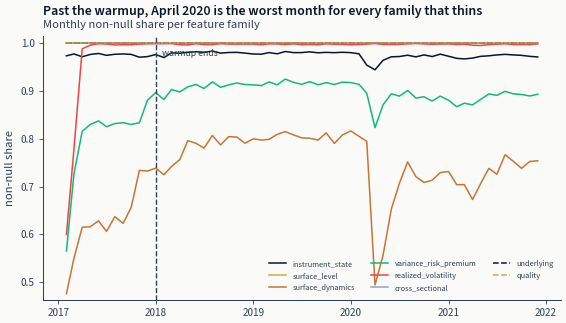

In [27]:
plot_coverage_through_time(
    coverage,
    warmup_boundary=WARMUP_END,
    title="Past the warmup, April 2020 is the worst month for every family that thins",
    subtitle="Monthly non-null share per feature family",
    alt=(
        "Line chart of non-null share by feature family by month, on a y-axis running from about "
        "0.47 to one, with a dashed vertical line at the start of 2018 marking the end of the "
        "warmup. The cross-sectional, quality, surface-level and underlying families sit flat at "
        "one for the whole sample. Realized volatility starts at about 0.6 and climbs to one "
        "within the first half of 2017, then stays there. To the left of the warmup line the "
        "variance-risk-premium and surface-dynamics families are still filling their longest "
        "windows and run at their lowest values of the whole chart, about 0.57 and 0.48. Past "
        "the warmup line, instrument state runs near 0.97, the variance-risk-premium family near "
        "0.90, and surface dynamics is the lowest line throughout, rising from about 0.73 in "
        "early 2018 to about 0.8 by 2019. All three dip sharply in April 2020 - to 0.945, 0.824 "
        "and 0.494 - which is the lowest each of them reaches after the warmup, and all three "
        "recover over the following year without regaining their 2019 level."
    ),
)

## F. What the features look like

Four properties decide whether this matrix can be used at all: the scale each feature arrives on,
whether the cross-section disagrees enough to rank on, how much of the set is one ordering under
several names, and how long a value lasts. `05_evaluation` is where the matrix is tested fold by
fold for whether any of it predicts.

### F2. The premium family, in every form it is carried

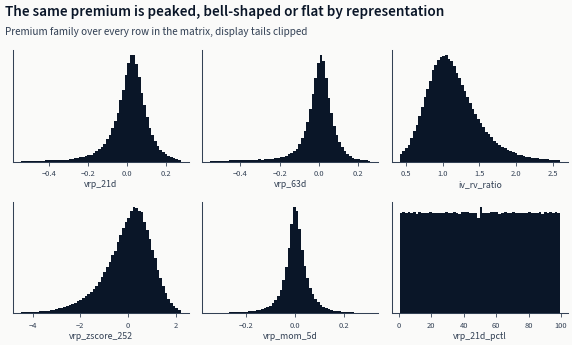

In [28]:
plot_feature_distributions(
    features,
    ["vrp_21d", "vrp_63d", "iv_rv_ratio", "vrp_zscore_252", "vrp_mom_5d", "vrp_21d_pctl"],
    title="The same premium is peaked, bell-shaped or flat by representation",
    subtitle="Premium family over every row in the matrix, display tails clipped",
    alt=(
        "Six histograms in two rows. The 21-session and 63-session premiums and the five-session "
        "premium change are all very sharply peaked just above zero with a long thin tail to the "
        "left and almost none to the right. The implied-to-realized ratio below them is a broad "
        "asymmetric hump peaking a little above one and running from about 0.4 to 2.6, and the "
        "252-session z-score is a broad bell centred near zero and skewed left, spanning about "
        "minus four to two. The percentile is flat across its whole zero-to-100 range, with a "
        "single narrow notch at the middle."
    ),
)

### F3. Cross-sectional dispersion through time

A cross-sectional strategy needs the cross-section to disagree. On a date where the band narrows
to nothing there is nothing to rank, whatever the average level of the premium.

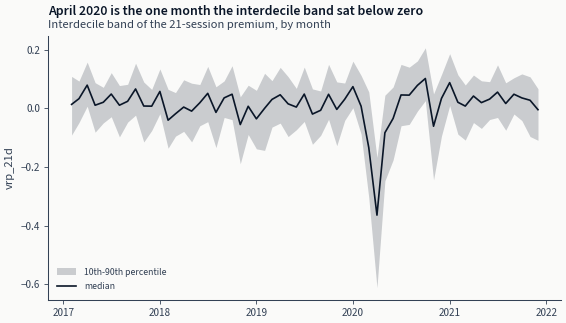

In [29]:
plot_cross_sectional_dispersion(
    features,
    "vrp_21d",
    every="1mo",
    title="April 2020 is the one month the interdecile band sat below zero",
    subtitle="Interdecile band of the 21-session premium, by month",
    alt=(
        "Shaded band of the 10th to 90th percentile of the 21-session premium by month, with the "
        "median drawn through it. The median sits between zero and 0.05 for almost the whole "
        "sample and the band is roughly plus or minus 0.1 wide, never narrowing to nothing. In "
        "April 2020 the median falls to about minus 0.32 and the band drops with it, its upper "
        "edge reaching about minus 0.08 and its lower edge about minus 0.7 - the only month in "
        "which the whole band lies below zero. Both recover by late 2020."
    ),
)

### F5. Redundancy structure

Two features that order the panel almost the same way add little to each other. Fit an
unpenalized linear model on both and it splits their shared contribution between two
coefficients that are then unstable from fold to fold - each can move a long way while the
pair's joint effect barely changes. A penalty on the coefficients damps that, and a tree does
not have the problem in the same form, but in every case the second column is buying less than
its own presence suggests. Grouping the features is how the notebook makes that visible before
any model is fitted.

Each column is replaced by its rank, the ranks are correlated pairwise - a Spearman
correlation - and the features are clustered on the distance $1 - |\rho|$, so a strongly
negative correlation counts as the same information as a strongly positive one. The dashed line
is the cut, drawn at the rank correlation named in the subtitle; every branch that has already
merged to the right of it is one group.

Two properties of that estimate are worth knowing before reading the tree. The ranking is over
rows pooled across symbols and dates, not within each date, so two features can land in one
group because they separate symbols the same way, because they move together through time, or
both - which is the right question for whether the matrix carries a column twice, and a
different question from whether they order the same names on the same Friday. And it is taken
on a fixed random sample of the rows rather than all of them, because the pairwise correlation
is quadratic in the columns; the sample is drawn under a fixed seed, so the tree is the same on
every run.

The groups are what this section produces. `05_evaluation` runs its own pooled Spearman
correlation later, over the features that reach its screen and on dates before the holdout, and
counts the pairs that clear the same threshold before printing the strongest of them.

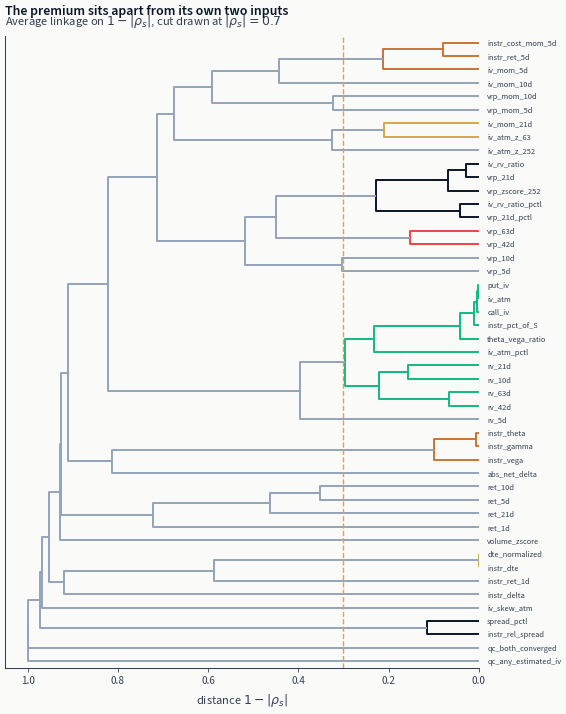

In [30]:
CUT = 0.7
clusters = plot_redundancy_clusters(
    features,
    FEATURE_COLUMNS,
    cut=CUT,
    title="The premium sits apart from its own two inputs",
    subtitle=r"Average linkage on $1 - |\rho_s|$, cut drawn at $|\rho_s| = 0.7$",
    alt=(
        "Dendrogram of every feature in the matrix. The largest cluster below the cut holds ten "
        "columns and mixes the two things the premium is the difference of: the three implied "
        "volatilities and the implied-volatility percentile join the four longer realized-"
        "volatility windows, together with the straddle's premium as a share of spot and the "
        "theta-vega ratio. The premium columns themselves sit in a separate branch, where the "
        "42-session and 63-session premiums pair off and the 21-session premium joins the ratio, "
        "the z-score and their percentiles. The momentum columns form a third branch. The "
        "straddle's relative spread and its percentile pair off tightly with each other and with "
        "nothing else, and that pair, the two quality controls and the skew all attach to the "
        "rest of the tree only near the root."
    ),
)

Cutting the redundancy tree at $|\rho_s| = 0.7$ leaves **26 clusters** across the **47**
columns, and only **8** of them hold more than one member. The largest holds **10**: the implied
volatilities and the realized volatilities are one ordering, which is what makes the premium -
their difference, and in a different cluster - the part of this matrix that is not already
carried by a volatility level.

In [31]:
sizes = Counter(clusters.values())
print(f"{len(sizes)} clusters over {len(FEATURE_COLUMNS)} features at cut {CUT}")
print(
    f"{sum(1 for n in sizes.values() if n > 1)} of them hold more than one column, "
    f"the largest {max(sizes.values())}"
)

26 clusters over 47 features at cut 0.7
8 of them hold more than one column, the largest 10


### F6. Persistence and rank stability

The right-hand panel compares the ordering across consecutive **decisions**, which
`config/setup.yaml` declares as a weekly Friday close. The autocorrelation on the left is of the
feature, not of the return, and it runs to twice the holding period: a feature whose value has
decayed before the position is closed cannot support this cadence, however well it predicts on
the day it is computed. It is estimated per symbol on pairs of dates exactly one lag apart and
summarized by the median over symbols, with a bootstrap interval over symbols; a correlation
pooled over every symbol-date pair would read high whenever symbols sit at different levels,
whether or not any one of them persists.

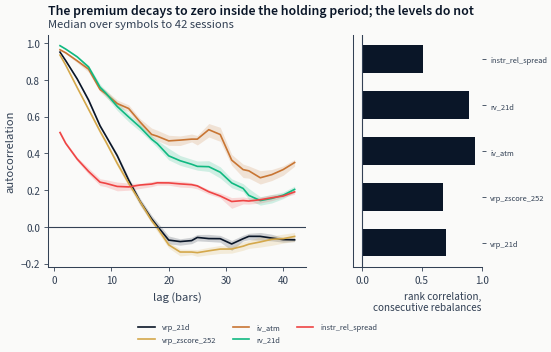

In [32]:
DECISION_DATES = (
    features.group_by(pl.col("timestamp").dt.truncate("1w"))
    .agg(pl.col("timestamp").max().alias("decision"))["decision"]
    .sort()
    .to_list()
)

plot_persistence(
    features,
    ["vrp_21d", "vrp_zscore_252", "iv_atm", "rv_21d", "instr_rel_spread"],
    entity="symbol",
    max_lag=2 * HOLD_SESSIONS,
    decision_dates=DECISION_DATES,
    title="The premium decays to zero inside the holding period; the levels do not",
    subtitle=f"Median over symbols to {2 * HOLD_SESSIONS} sessions",
    alt=(
        "Two panels. On the left, autocorrelation against lag. The 21-session premium and its "
        "252-session z-score both start near 0.94 at lag one and fall almost on top of each "
        "other in a near-straight line, crossing zero at lag 20 and lag 18 respectively, reaching "
        "about minus 0.14 near lag 25 and coming back to about minus 0.06 by lag 42. Implied "
        "volatility and "
        "21-session realized volatility start slightly higher, near 0.97, and decay far more "
        "slowly, still at 0.35 and 0.20 at lag 42 and never crossing zero. The relative spread "
        "starts much lower, at about 0.51, and flattens near 0.19. The bootstrap ribbons are "
        "narrow throughout. On the right, the cross-sectional rank correlation between "
        "consecutive weekly decisions puts implied volatility highest at 0.95 and realized "
        "volatility next at 0.90, the premium and its z-score together near 0.69, and the "
        "relative spread lowest at 0.51."
    ),
)

## G. Emit

The parquet is written with a sidecar recording the digest of its values, its row count and key
columns, and the digest of what it was built from. This stage reads no upstream case-study
artifact, so the sidecar records the two loaded panels alone, each restricted to the columns and
window actually consumed - which is what answers "which market-data vintage produced these
values". The digest is computed over content rather than file bytes, so row order and parquet
metadata leave it alone and any feature value moves it.

In [33]:
record = write_artifact(
    features,
    FEATURES_DIR / "financial.parquet",
    keys=PANEL_KEY,
    written_by="case_studies/sp500_options/03_financial_features.py",
    inputs={
        "load_sp500_options_straddles": value_digest(quotes),
        "load_sp500_daily_bars": value_digest(
            underlying.select(["timestamp", *SEGMENT, "close", "adj_factor", "volume"])
        ),
    },
)
print(f"Wrote {display_path(FEATURES_DIR / 'financial.parquet')}, digest {record['digest']}")

Wrote ~/ml4t/artifacts/case_studies/sp500_options/features/financial.parquet, digest fc8c04b2451bf8a7


## Key takeaways

- **Count the window on the grid the quantity lives on, not on the rows it happens to occupy.**
  An intermittently listed instrument makes `shift(21)` mean 21 quotes rather than 21 sessions,
  and the two differ on nearly half of this panel. Reindexing onto the underlying's sessions is
  what makes the register's declared lookbacks true.
- **State the timing contract before writing the feature.** The register fixes each family's
  lookback and lag in the configuration, and the warmup assertion, the timing figure and the
  review a reader can run all read those numbers rather than re-deriving them from the code.
- **Say what a column is when its name suggests something better.** The change in the price of a
  reselected 30-day straddle is not a return anyone held, and only the prose can carry that.
- **Check that the holdout was untouched by rebuilding, not by reading the code.** Recomputing
  the panel with the later dates withheld and comparing every value catches any transform that
  fits across the sample, including the ones nobody thought to flag.
- **Read the matrix before modelling it.** Distribution, dispersion, redundancy and decay each
  rule out a use: a feature with no cross-sectional spread cannot rank, and one whose ordering
  decays inside the holding period cannot be traded at this cadence.

### Known limitations

- The premium contrasts a forward-looking quote with a backward-looking estimate. It is a
  premium only to the extent realized volatility persists over the contract's life, which is an
  assumption this notebook carries rather than tests.
- The minimum-observation rule buys coverage with comparability: a 252-session z-score built
  from 202 quotes and one built from 252 are not the same statistic, and nothing downstream
  knows which it received.
- Only a single 30-day at-the-money straddle is materialized per symbol-session, so the term
  structure and the wings of the surface are not observable here at all. The skew column is the
  residual between two legs at one strike, not a smile.
- Every feature here is a rule written in advance. `04_model_based_features` adds the features
  that are themselves model outputs, where the rule is estimated from the data.